# Phishing Email Detection Using NLP
**Student:** Damla Yüksel  
**Course:** Natural Language Processing  
**Dataset:** [Phishing Email Detection — Kaggle](https://www.kaggle.com/datasets/subhajournal/phishingemails)  

---
**Goal:** Detect phishing emails cyberattacks designed to steal passwords, credit card numbers, or personal information  using Natural Language Processing and Machine Learning.

| Class | Description |
|-------|-------------|
| **Safe Email** | Legitimate message |
| **Phishing Email** | Malicious message attempting to deceive the user |

## Step 1 — Import Libraries

In [29]:
import re
import io
import os
import warnings
import urllib.request
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

for pkg in ['stopwords', 'punkt', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

SAFE_COLOR  = '#2196F3'
PHISH_COLOR = '#E74C3C'
print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2 — Load Dataset


https://www.kaggle.com/datasets/subhajournal/phishingemails


The dataset contains 18,000+ emails labeled as Safe Email or Phishing Email.

In [30]:

df = None

if os.path.exists('emails.csv'):
    df = pd.read_csv('emails.csv')
    print('Loaded from emails.csv (Kaggle)')
elif os.path.exists('phishing_email.csv'):
    df = pd.read_csv('phishing_email.csv')
    print('Loaded from phishing_email.csv')

if df is None:
    raise FileNotFoundError("Put emails.csv in the same folder as this notebook.")

df.columns = df.columns.str.strip()

# Normalize column names : label / message
if 'spam' in df.columns and 'text' in df.columns:
    df = df[['spam', 'text']].rename(columns={'text': 'message'})
    df['label'] = df['spam'].map({1: 'Phishing Email', 0: 'Safe Email'})
    df = df[['label', 'message']]
elif 'Email Type' in df.columns and 'Email Text' in df.columns:
    df = df[['Email Type', 'Email Text']].rename(columns={'Email Type': 'label', 'Email Text': 'message'})
elif 'label' in df.columns and 'text' in df.columns:
    df = df[['label', 'text']].rename(columns={'text': 'message'})

df = df.dropna(subset=['label', 'message']).reset_index(drop=True)
df['label'] = df['label'].str.strip()

print(f'Dataset shape : {df.shape}')
print(f'Classes       : {df["label"].unique().tolist()}')

# Show clean examples from each class
pd.concat([
    df[df['label']=='Safe Email'].head(3),
    df[df['label']=='Phishing Email'].head(3)
]).reset_index(drop=True)

Loaded from emails.csv (Kaggle)
Dataset shape : (5728, 2)
Classes       : ['Phishing Email', 'Safe Email']


,label,message
0,Safe Email,"Subject: hello guys , i ' m "" bugging you "" f..."
1,Safe Email,Subject: sacramento weather station fyi - - ...
2,Safe Email,Subject: from the enron india newsdesk - jan 1...
3,Phishing Email,Subject: naturally irresistible your corporate...
4,Phishing Email,Subject: the stock trading gunslinger fanny i...
5,Phishing Email,Subject: unbelievable new homes made easy im ...


## Step 3 — Explore Dataset

Class distribution:
  Safe Email          :   4360  (76.1%)
  Phishing Email      :   1368  (23.9%)


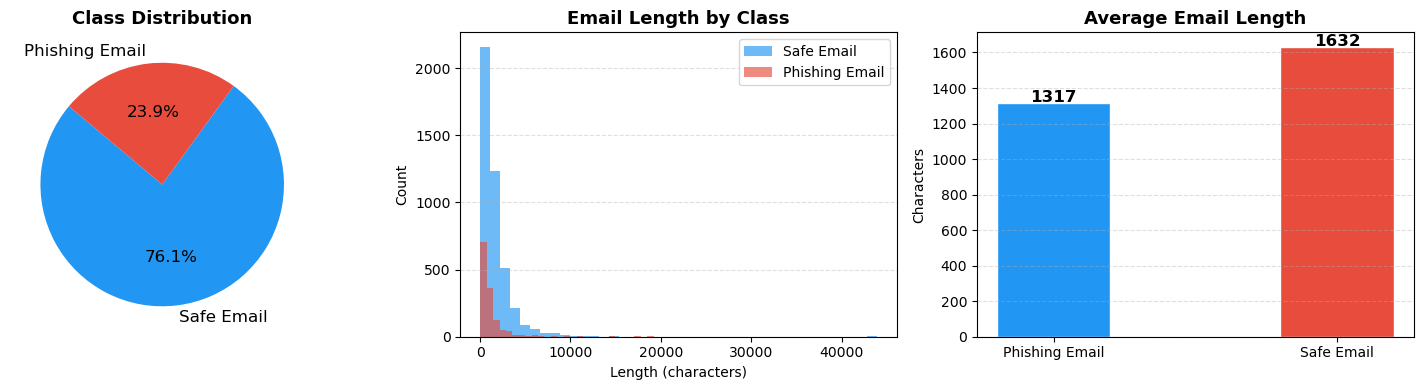

In [31]:
counts = df['label'].value_counts()
print('Class distribution:')
for label, count in counts.items():
    print(f'  {label:<20}: {count:>6}  ({count/len(df)*100:.1f}%)')

df['msg_len'] = df['message'].str.len()
pie_colors = [SAFE_COLOR, PHISH_COLOR]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=pie_colors[:len(counts)], startangle=140,
            textprops={'fontsize': 12})
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

for label, color in zip(counts.index, pie_colors):
    axes[1].hist(df[df['label']==label]['msg_len'], bins=40,
                 alpha=0.65, color=color, label=label)
axes[1].set_title('Email Length by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

avg_len = df.groupby('label')['msg_len'].mean()
bars = axes[2].bar(avg_len.index, avg_len.values,
                   color=pie_colors[:len(avg_len)],
                   edgecolor='white', width=0.4)
for bar, val in zip(bars, avg_len.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:.0f}', ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Average Email Length', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Characters')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Step 4 — Clean the Sentences (Text Preprocessing)

| Step | Operation | Example |
|------|-----------|--------|
| 1 | Lowercasing | `URGENT` → `urgent` |
| 2 | URL removal | `http://bit.ly/x` → ` ` |
| 3 | Punctuation & digit removal | `verify!` → `verify` |
| 4 | Tokenization | `verify account` → `[verify, account]` |
| 5 | Stop word removal | `your account` → `[account]` |
| 6 | Stemming | `suspended` → `suspend` |

In [32]:
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text   = str(text).lower()
    text   = re.sub(r'http\S+|www\.\S+', ' ', text)
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t and t not in stop_words]
    return ' '.join(tokens)

df['clean'] = df['message'].apply(preprocess)

print('Preprocessing examples:\n')
for label in df['label'].unique():
    row = df[df['label'] == label].iloc[0]
    print(f'[{label.upper()}]')
    print(f'  Original : {row["message"][:100]}')
    print(f'  Cleaned  : {row["clean"][:100]}')
    print()

Preprocessing examples:

[PHISHING EMAIL]
  Original : Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : 
  Cleaned  : subject natur irresist corpor ident lt realli hard recollect compani market full suqgest inform isov

[SAFE EMAIL]
  Original : Subject: hello guys ,  i ' m " bugging you " for your completed questionnaire and for a one - page  
  Cleaned  : subject hello guy bug complet questionnair one page bio statement thought busi edu new economi recor



## Step 5 — Phishing Feature Engineering (Cybersecurity)

We extract **6 domain-specific features** that are known phishing indicators:

| Feature | Why it matters |
|---------|----------------|
| `has_url` | Phishing emails almost always contain a malicious link |
| `shortened_url` | Attackers hide real destinations using bit.ly, tinyurl |
| `urgency_words` | 'URGENT', 'immediately', 'expire' create panic |
| `credential_words` | 'password', 'verify', 'login' are classic social engineering |
| `threat_words` | 'suspended', 'blocked', 'arrest' manipulate through fear |
| `many_subdomains` | Fake domains like login.bank.verify.ru disguise real URL |

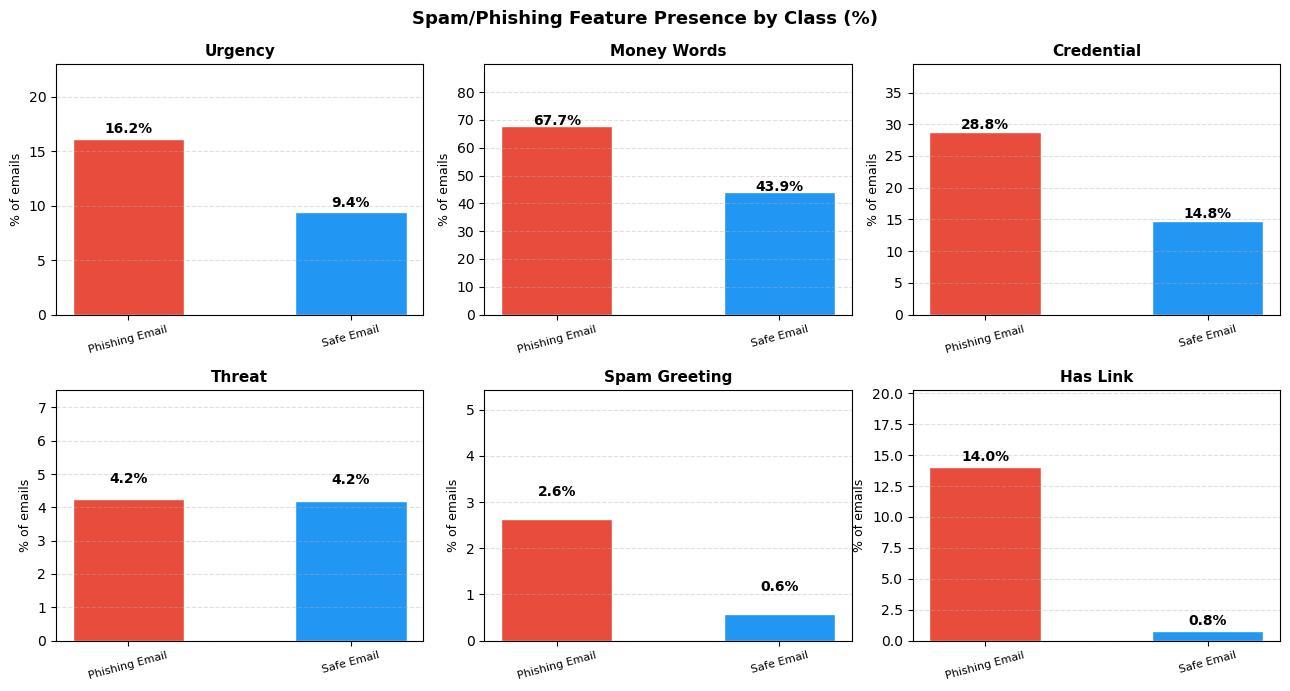

In [34]:
URGENCY_KW    = r"urgent|immediately|expire|limited|act now|asap|today only|hurry"
MONEY_KW      = r"free|win|winner|prize|cash|offer|discount|deal|save|earn|reward|gift|bonus"
CREDENTIAL_KW = r"verify|password|login|account|confirm|validate|credential|identity|click here"
THREAT_KW     = r"suspend|block|arrest|penalty|lawsuit|closed|disabled|restricted|banned"
GREETING_KW   = r"dear (customer|user|friend|sir|madam|member|valued|winner)"

def extract_phishing_features(text):
    t = str(text).lower()
    return [
        int(bool(re.search(URGENCY_KW,    t))),
        int(bool(re.search(MONEY_KW,      t))),
        int(bool(re.search(CREDENTIAL_KW, t))),
        int(bool(re.search(THREAT_KW,     t))),
        int(bool(re.search(GREETING_KW,   t))),
        int(len(re.findall(r"http\S+|www\.\S+|click here", t)) > 0),
    ]

feat_names = ["urgency", "money_words", "credential", "threat", "spam_greeting", "has_link"]
all_feats  = np.array([extract_phishing_features(t) for t in df["message"]])
feat_df    = pd.DataFrame(all_feats, columns=feat_names)
feat_df["label"] = df["label"].values

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, feat in zip(axes, feat_names):
    group  = feat_df.groupby("label")[feat].mean() * 100
    labels = list(group.index)
    values = list(group.values)
    bar_colors = [PHISH_COLOR if "Phishing" in l else SAFE_COLOR for l in labels]
    bars = ax.bar(labels, values, color=bar_colors, edgecolor="white", width=0.5)
    ax.set_title(feat.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_ylabel("% of emails", fontsize=9)
    ax.tick_params(axis="x", rotation=15, labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(0, max(values) * 1.3 + 2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Spam/Phishing Feature Presence by Class (%)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 6 — Convert Words into Numbers (Vectorization)
Combine **TF-IDF** (text features) with the **6 phishing features** into one matrix.

In [35]:
X_text = df['clean']
X_raw  = df['message']
y      = df['label']

X_tr_txt, X_te_txt, X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_text, X_raw, y, test_size=0.20, random_state=42, stratify=y
)

tfidf_vec     = TfidfVectorizer(min_df=2, ngram_range=(1,2), sublinear_tf=True, max_features=15000)
X_train_tfidf = tfidf_vec.fit_transform(X_tr_txt)
X_test_tfidf  = tfidf_vec.transform(X_te_txt)

X_train_phish = csr_matrix(np.array([extract_phishing_features(t) for t in X_tr_raw]))
X_test_phish  = csr_matrix(np.array([extract_phishing_features(t) for t in X_te_raw]))

X_train = hstack([X_train_tfidf, X_train_phish])
X_test  = hstack([X_test_tfidf,  X_test_phish])

print(f'Train size     : {X_train.shape[0]:,} emails')
print(f'Test size      : {X_test.shape[0]:,} emails')
print(f'Total features : {X_train.shape[1]:,}  (TF-IDF + 6 phishing features)')

Train size     : 4,582 emails
Test size      : 1,146 emails
Total features : 15,006  (TF-IDF + 6 phishing features)


## Step 7 — Train Models

In [37]:
models = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=4.0),
    'Linear SVM'         : LinearSVC(C=1.0),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f'Trained: {name}')

Trained: Naive Bayes
Trained: Logistic Regression
Trained: Linear SVM


## Step 8 — Test Models

In [38]:
pos_label = [l for l in y.unique() if 'Phishing' in l or 'phishing' in l][0]
results   = []
preds     = {}

for name, model in trained.items():
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=pos_label, average='binary'),
        'Recall'   : recall_score(y_test, y_pred, pos_label=pos_label, average='binary'),
        'F1-Score' : f1_score(y_test, y_pred, pos_label=pos_label, average='binary'),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Naive Bayes            0.9817     0.9961  0.9270    0.9603
Logistic Regression    0.9921     0.9889  0.9781    0.9835
Linear SVM             0.9913     0.9818  0.9818    0.9818


## Step 9 — Show Accuracy & Charts

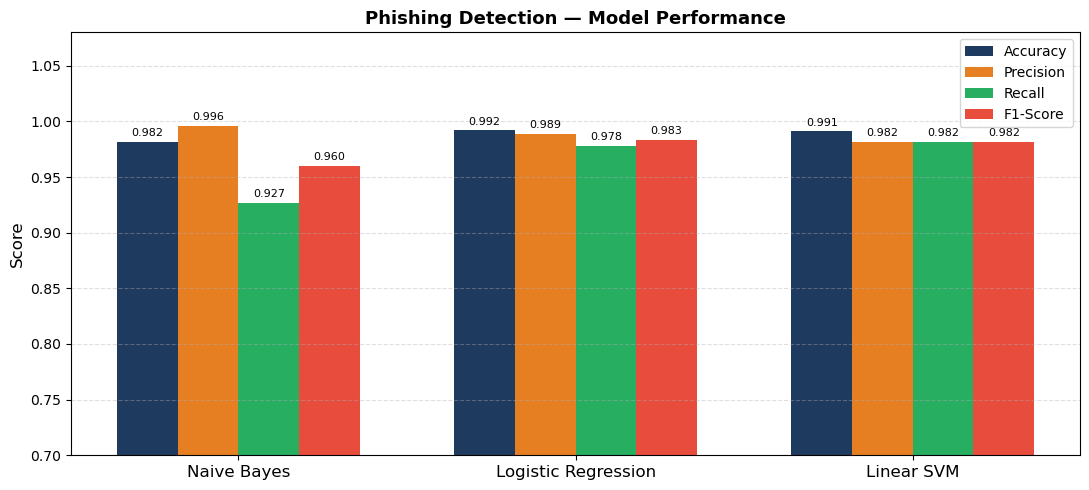

In [39]:
metrics    = ['Accuracy','Precision','Recall','F1-Score']
m_names    = list(results_df.index)
x          = np.arange(len(m_names))
w          = 0.18
met_colors = ['#1E3A5F','#E67E22','#27AE60','#E74C3C']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, color) in enumerate(zip(metrics, met_colors)):
    vals = results_df[metric].values
    bars = ax.bar(x + (i-1.5)*w, vals, w, label=metric, color=color)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.003, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(m_names, fontsize=12)
ax.set_ylim(0.70, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Phishing Detection — Model Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

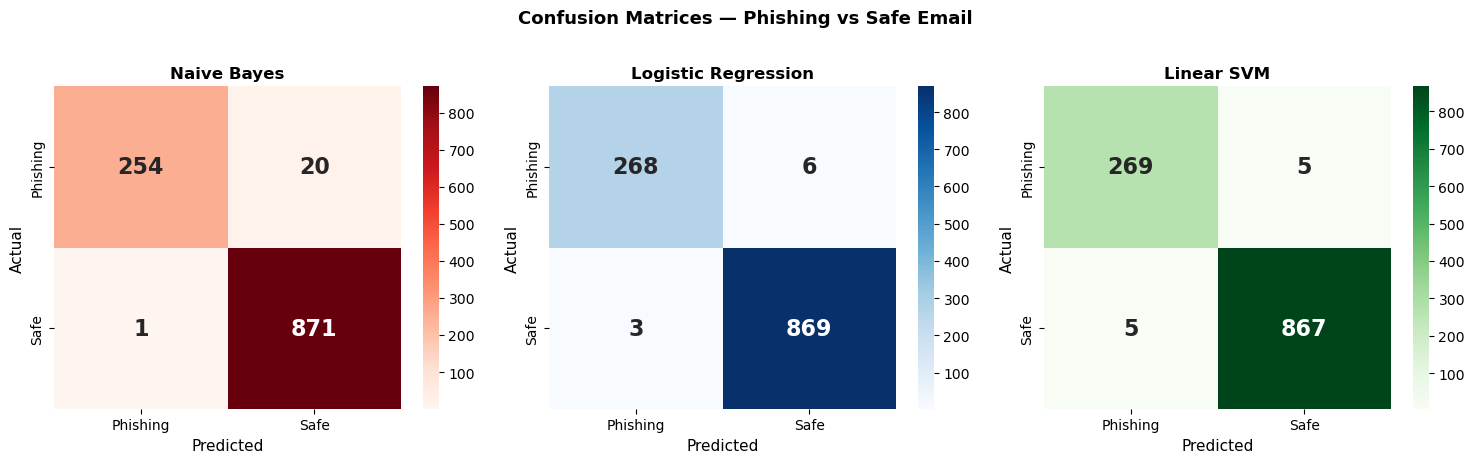

In [40]:
label_order = sorted(y.unique())
tick_labels = ['Phishing', 'Safe']
fig, axes   = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, y_pred), cmap in zip(axes, preds.items(), ['Reds','Blues','Greens']):
    cm = confusion_matrix(y_test, y_pred, labels=label_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=tick_labels, yticklabels=tick_labels,
                ax=ax, annot_kws={'size':16,'weight':'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices — Phishing vs Safe Email',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

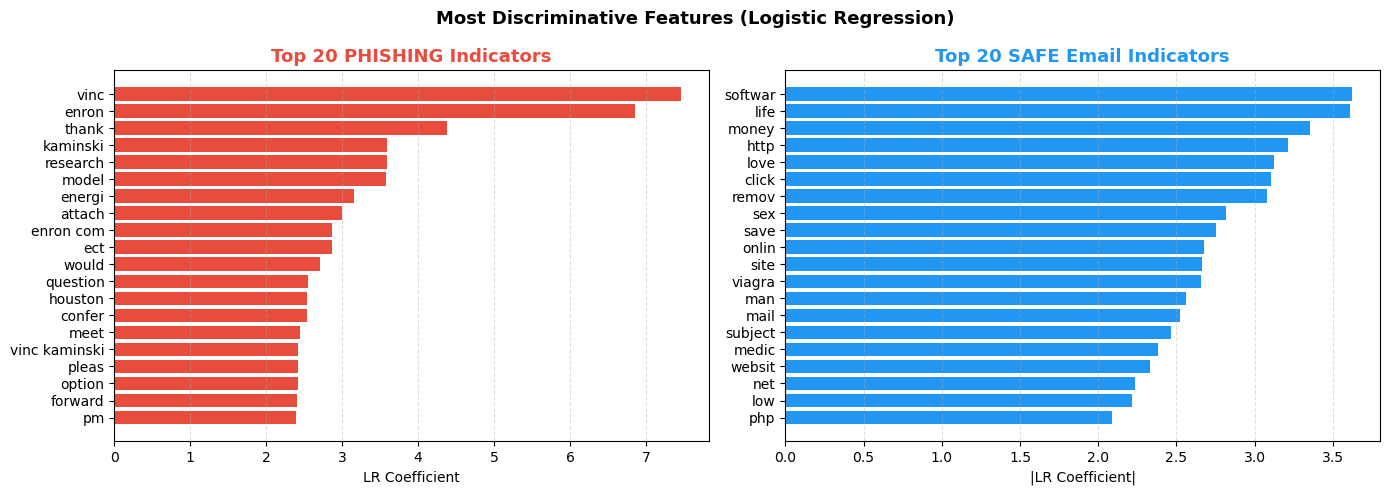

In [41]:
lr            = trained['Logistic Regression']
feature_names = np.array(list(tfidf_vec.get_feature_names_out()) + feat_names)
phish_idx     = list(lr.classes_).index(pos_label)
coefs         = lr.coef_[phish_idx] if lr.coef_.shape[0]>1 else lr.coef_[0]

top_phish = np.argsort(coefs)[-20:][::-1]
top_safe  = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(feature_names[top_phish][::-1], coefs[top_phish][::-1], color=PHISH_COLOR)
axes[0].set_title('Top 20 PHISHING Indicators', fontsize=13, fontweight='bold', color=PHISH_COLOR)
axes[0].set_xlabel('LR Coefficient')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

axes[1].barh(feature_names[top_safe][::-1], np.abs(coefs[top_safe][::-1]), color=SAFE_COLOR)
axes[1].set_title('Top 20 SAFE Email Indicators', fontsize=13, fontweight='bold', color=SAFE_COLOR)
axes[1].set_xlabel('|LR Coefficient|')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Most Discriminative Features (Logistic Regression)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

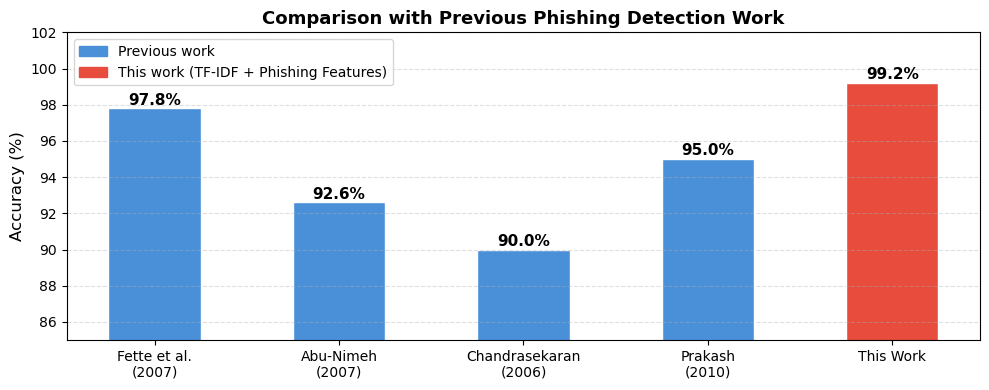

In [42]:
best_acc = results_df['Accuracy'].max() * 100
prev = pd.DataFrame({
    'Study'   : ['Fette et al.\n(2007)','Abu-Nimeh\n(2007)','Chandrasekaran\n(2006)','Prakash\n(2010)','This Work'],
    'Accuracy': [97.8, 92.6, 90.0, 95.0, best_acc],
    'color'   : ['#4A90D9','#4A90D9','#4A90D9','#4A90D9','#E74C3C'],
})

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(prev['Study'], prev['Accuracy'], color=prev['color'], edgecolor='white', width=0.5)
ax.set_ylim(85, 102)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Comparison with Previous Phishing Detection Work', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars, prev['Accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#4A90D9', label='Previous work'),
    mpatches.Patch(color='#E74C3C', label='This work (TF-IDF + Phishing Features)'),
], fontsize=10)
plt.tight_layout()
plt.show()

## Best Model & Summary

In [43]:
best_name  = results_df['F1-Score'].idxmax()
best_model = trained[best_name]
print('='*55)
print(f'  BEST MODEL : {best_name}')
print(f'  ACCURACY   : {results_df.loc[best_name,"Accuracy"]:.4f}')
print(f'  F1-SCORE   : {results_df.loc[best_name,"F1-Score"]:.4f}')
print('='*55)
print(classification_report(y_test, preds[best_name], digits=4))

  BEST MODEL : Logistic Regression
  ACCURACY   : 0.9921
  F1-SCORE   : 0.9835
                precision    recall  f1-score   support

Phishing Email     0.9889    0.9781    0.9835       274
    Safe Email     0.9931    0.9966    0.9948       872

      accuracy                         0.9921      1146
     macro avg     0.9910    0.9873    0.9892      1146
  weighted avg     0.9921    0.9921    0.9921      1146



## Live Demo — Phishing Detector
Type any email and the model will tell you if it is **phishing** or **safe**.

In [47]:
def predict(email_text):
    cleaned    = preprocess(email_text)
    tfidf_feat = tfidf_vec.transform([cleaned])
    phish_feat = csr_matrix([extract_phishing_features(email_text)])
    combined   = hstack([tfidf_feat, phish_feat])
    result     = best_model.predict(combined)[0]
    icon       = ' PHISHING' if 'Phishing' in result else 'SAFE'
    print(f'Email  : {email_text[:90]}')
    print(f'Result : {icon}')
    print()

predict('Hi team, the project meeting is rescheduled to Friday at 2pm.')
predict('URGENT: Your account has been suspended. Verify now at http://bit.ly/secure-login')
predict('Please find attached the invoice for last month services.')
predict('Your password will expire in 24h. Update here: http://netflix-billing.xyz/login')
predict('Congratulations! You won a $5000 Amazon gift card. Claim: http://tinyurl.com/prize99')

Email  : Hi team, the project meeting is rescheduled to Friday at 2pm.
Result : SAFE

Email  : URGENT: Your account has been suspended. Verify now at http://bit.ly/secure-login
Result :  PHISHING

Email  : Please find attached the invoice for last month services.
Result : SAFE

Email  : Your password will expire in 24h. Update here: http://netflix-billing.xyz/login
Result : SAFE

Email  : Congratulations! You won a $5000 Amazon gift card. Claim: http://tinyurl.com/prize99
Result :  PHISHING



In [50]:

my_email = "Dear customer, your bank account will be closed unless you verify at http://bank-secure.ru/login"
predict(my_email)

Email  : Dear customer, your bank account will be closed unless you verify at http://bank-secure.ru
Result :  PHISHING



## (Optional) Save Model for Email Scanner
Run this cell to save the trained model. Then you can use  to scan your real emails.

In [ ]:
# ── Save model for Email Scanner (optional) ──────────────────
import joblib

joblib.dump(best_model, "phishing_model.pkl")
joblib.dump(tfidf_vec,  "tfidf_vectorizer.pkl")

print("Model saved → phishing_model.pkl")
print("Vectorizer saved → tfidf_vectorizer.pkl")
print("You can now run: python email_scanner.py")